# Negociação de Pares — Método da Cointegração (Rad et al., 2016)

Implementa a **fase de negociação** via cointegração de Engle-Granger,
usando os pares selecionados em `pairs_formation_coint.ipynb`.

Para cada par em cada janela:
1. Normaliza os preços do período de negociação a partir do **início da formação** — mesma base que gerou `beta`, `alpha`, `spread_media` e `spread_desvio`
2. Calcula o **spread de cointegração** com os parâmetros fixos da formação:
   $$\varepsilon_t = Q_2(t) - \alpha - \beta \cdot Q_1(t)$$
3. Calcula o **z-score**: $z(t) = (\varepsilon_t - \mu) / \sigma$
4. Abre posição quando $|z| > \delta$, fecha quando $z \to 0$
5. Retorno diário usa **pesos beta-neutral** (Rad et al., seção 4.2.2):
   $$r_{\text{par}}(t) = \text{position}(t-1) \times \frac{\beta \cdot r_1(t) - r_2(t)}{\beta + 1}$$

**Referência:** Rad, H., Low, R.K.Y. & Faff, R. (2016). *The profitability of pairs trading strategies: distance, cointegration and copula methods.* Quantitative Finance, 16(10), 1541–1558.

## 1. Setup

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# === Parâmetros da estratégia ===
DELTA     = 2.0    # gatilho de entrada: abre posição quando |z| > DELTA
STOP      = None   # Rad et al. não usa stop-loss — posições fecham por z→0 ou fim do período
SIGMA_MIN = 0.005  # exclui pares com sigma patológico (ghost tickers ~ 0.00002)

# === Filtro de qualidade de dados ===
# Spike positivo extremo = corrupção de dados. Usamos .max() (não .abs().max())
# para preservar quedas reais (falências) e capturar as perdas corretamente.
# None = sem filtro.
MAX_RETORNO_DIA = 0.90

# === Convenção do portfólio ===
# True  — "committed capital" (Rad et al. / Gatev et al.):
#         denominador = N pares fixo; pares inativos contribuem 0.
# False — "fully invested":
#         denominador = pares com posição ativa no dia.
COMMITTED_CAPITAL = True

# === Filtro de período (mês no formato 'YYYY-MM') ===
PERIODO_INICIO = None   # ex: '1992-01'
PERIODO_FIM    = None   # ex: '2020-12'

META_COLS = ['year', 'semester', 'period', 'day_in_semester', 'total_days_sem']

## 2. Carregando os dados

In [65]:
pares_raw = pd.read_csv('output/pares_formados_coint.csv')
df        = pd.read_csv('../../data_bases/base_unificada.csv', parse_dates=['date'])
df        = df.set_index('date')

colunas_preco    = [c for c in df.columns if c not in META_COLS]
meses_por_linha  = pd.PeriodIndex(df.index, freq='M')

# Filtro de período sobre o início do semestre de negociação
pares = pares_raw.copy()
if PERIODO_INICIO is not None:
    pares = pares[pares['negociacao_inicio'] >= PERIODO_INICIO]
if PERIODO_FIM is not None:
    pares = pares[pares['negociacao_fim'] <= PERIODO_FIM]

print(f"Pares disponíveis : {len(pares_raw):,} ({pares_raw['janela'].nunique()} janelas)")
if PERIODO_INICIO or PERIODO_FIM:
    ini = PERIODO_INICIO or pares_raw['negociacao_inicio'].min()
    fim = PERIODO_FIM    or pares_raw['negociacao_fim'].max()
    print(f"Período filtrado  : {ini} → {fim}  ({len(pares):,} pares, {pares['janela'].nunique()} janelas)")
else:
    print("Período filtrado  : todo o histórico")
print(f"Base de preços    : {df.shape[0]:,} dias × {len(colunas_preco):,} tickers")

Pares disponíveis : 8,177 (409 janelas)
Período filtrado  : todo o histórico
Base de preços    : 8,939 dias × 1,343 tickers


## 3. Lógica de negociação

### Spread e z-score

O spread de cointegração usa os parâmetros **fixos** estimados na formação:

$$\varepsilon_t = Q_2(t) - \alpha - \beta \cdot Q_1(t)$$

$$z(t) = \frac{\varepsilon_t - \mu}{\sigma}$$

onde $\mu \approx 0$ (propriedade do OLS) e $\sigma$ é o desvio-padrão do resíduo na formação.
Os preços são normalizados a partir do **início da formação**: $Q_i(t) = P_i(t) / P_i(t_0^{\text{form}})$.

### Regras de entrada e saída

| Condição | Posição | Alocação (Rad et al., seção 4.2.2) |
|---|---|---|
| $z > +\delta$ | `+1` | LONG \$1 em $Q_1$, SHORT \$1/β em $Q_2$ |
| $z < -\delta$ | `−1` | LONG \$1 em $Q_2$, SHORT \$β em $Q_1$ |
| $z \to 0$ | `0` (fecha) | reversão concluída |
| fim do período | `0` (fecha forçado) | encerra todas as posições abertas |

### Retorno beta-neutral

O P&L bruto da posição por \$1 da perna short é:

$$r_{\text{par}}(t) = \text{position}(t-1) \times [\beta \cdot r_1(t) - r_2(t)]$$

**Verificação de sinais:**
- `position = +1` (z > δ, $Q_2$ caro): return = $\beta r_1 - r_2$ → lucro quando $Q_2$ cai ou $Q_1$ sobe ✓  
- `position = −1` (z < −δ, $Q_2$ barato): return = $-({\beta r_1 - r_2}) = r_2 - \beta r_1$ → lucro quando $Q_2$ sobe ✓  
- Quando $\beta = 1$: reduz a $r_1 - r_2$, idêntico ao método da distância

> **Nota sobre normalização:** Rad et al. é ambíguo quanto ao denominador do retorno. Aqui usamos o P&L bruto (sem dividir por $\beta + 1$), mantendo a mesma escala do método da distância e facilitando a comparação entre métodos. O Sharpe é invariante à escolha do denominador.

### Lag de posição (convenção de execução)

A decisão é tomada ao **fechamento do dia $t$**; a execução começa no **dia $t+1$**, implementado via `np.roll(positions, 1)`.

## 4. Funções

In [66]:
def simular_par_coint(precos_form, precos_neg, alpha, beta, mu, sigma,
                      delta=None, stop=None):
    """
    Simula a negociação de um par via cointegração de Engle-Granger.

    precos_form : DataFrame (T × 2) com preços no período de formação
    precos_neg  : DataFrame (τ × 2) com preços no período de negociação
    alpha, beta : parâmetros OLS estimados na formação
    mu, sigma   : média e desvio do resíduo OLS na formação

    Convenção de sinal (position é a direção do trade sobre o spread β·r1 − r2):
      position = +1  →  z > +δ: spread alto, Q2 caro  →  LONG Q1 ($1),  SHORT Q2 ($1/β)
      position = -1  →  z < -δ: spread baixo, Q2 barato →  LONG Q2 ($1), SHORT Q1 ($β)
      position =  0  →  fora do mercado

    O retorno do dia é position × (β·r1 − r2): positivo quando o spread se move
    a favor da posição. Quando β ≈ 1 reduz a (r1 − r2), análogo ao método da distância.
    """
    if delta is None:
        delta = DELTA
    if stop is None:
        stop = STOP

    if sigma == 0:
        return None

    a1, a2 = precos_form.columns[0], precos_form.columns[1]
    precos_form = precos_form.sort_index()
    precos_neg  = precos_neg.sort_index()

    # Normaliza negociação a partir do início da formação (mesma base do OLS)
    P0    = precos_form.iloc[0]
    Q_neg = precos_neg / P0

    # Spread de cointegração: resíduo do OLS com parâmetros fixos da formação
    spread = Q_neg[a2] - alpha - beta * Q_neg[a1]
    z      = (spread - mu) / sigma
    z_arr  = z.values

    # Simula posições dia a dia
    positions = np.zeros(len(z_arr))
    pos = 0
    for t, zt in enumerate(z_arr):
        if pos == 0:
            if zt > delta:
                pos = +1   # spread alto (Q2 caro)  → aposta na queda do spread
            elif zt < -delta:
                pos = -1   # spread baixo (Q2 barato) → aposta na alta do spread
        else:
            if stop is not None and abs(zt) > stop:
                pos = 0    # stop-loss
            elif pos == +1 and zt <= 0:
                pos = 0    # spread reverteu à média → fecha
            elif pos == -1 and zt >= 0:
                pos = 0    # spread reverteu à média → fecha
        positions[t] = pos

    r1 = precos_neg[a1].pct_change().fillna(0).values
    r2 = precos_neg[a2].pct_change().fillna(0).values

    positions_lag    = np.roll(positions, 1)
    positions_lag[0] = 0

    # Retorno = direção × variação do spread (β·r1 − r2), por $1 da perna short.
    retorno = positions_lag * (beta * r1 - r2)

    return pd.DataFrame({
        'spread':         spread.values,
        'z':              z_arr,
        'position':       positions,
        'position_lag':   positions_lag,
        'retorno_diario': retorno,
    }, index=z.index)


def contar_trades(positions):
    """Retorna (n_abertos, n_fechados_normal, n_forcados)."""
    pos = np.asarray(positions)
    entradas       = np.sum((pos[1:] != 0) & (pos[:-1] == 0))
    if pos[0] != 0:
        entradas  += 1
    saidas_normais = np.sum((pos[:-1] != 0) & (pos[1:] == 0))
    forcado        = 1 if pos[-1] != 0 else 0
    return int(entradas), int(saidas_normais), int(forcado)

## 5. Simulação completa

Para cada par, **quatro filtros de exclusão** são aplicados antes de acumular o resultado:
1. `sigma < SIGMA_MIN` — ghost tickers com sigma ~ 0
2. Ticker não encontrado na base de preços
3. Dados ausentes no período de formação ou negociação
4. `MAX_RETORNO_DIA` — exclui pares com retorno diário anômalo (OTC penny stocks corrompidos)

In [67]:
resultados_pares  = []
retornos_por_data = {}

n_skip_sigma   = 0
n_skip_ticker  = 0
n_skip_dados   = 0
n_skip_outlier = 0
sem_dados_log  = []   # captura os pares pulados por dados ausentes

for _, par in pares.iterrows():
    a1    = par['ativo1']
    a2    = par['ativo2']
    alpha = par['alpha']
    beta  = par['beta']
    mu    = par['spread_media']
    sigma = par['spread_desvio']

    if sigma < SIGMA_MIN:
        n_skip_sigma += 1
        continue

    if a1 not in df.columns or a2 not in df.columns:
        n_skip_ticker += 1
        continue

    form_inicio = pd.Period(par['formacao_inicio'], freq='M')
    form_fim    = pd.Period(par['formacao_fim'],    freq='M')
    neg_inicio  = pd.Period(par['negociacao_inicio'], freq='M')
    neg_fim     = pd.Period(par['negociacao_fim'],    freq='M')

    mask_form = (meses_por_linha >= form_inicio) & (meses_por_linha <= form_fim)
    mask_neg  = (meses_por_linha >= neg_inicio)  & (meses_por_linha <= neg_fim)

    precos_form = df.loc[mask_form, [a1, a2]].dropna()
    precos_neg  = df.loc[mask_neg,  [a1, a2]].dropna()

    if len(precos_form) == 0 or len(precos_neg) == 0:
        # Diagnóstico: quantos dias brutos existem (antes do dropna) e qual coluna tem NaN
        dias_form_bruto = mask_form.sum()
        dias_neg_bruto  = mask_neg.sum()
        nan_form_a1 = df.loc[mask_form, a1].isna().sum()
        nan_form_a2 = df.loc[mask_form, a2].isna().sum()
        nan_neg_a1  = df.loc[mask_neg,  a1].isna().sum()
        nan_neg_a2  = df.loc[mask_neg,  a2].isna().sum()
        sem_dados_log.append({
            'ativo1': a1, 'ativo2': a2,
            'janela': par['janela'],
            'neg_inicio': par['negociacao_inicio'],
            'dias_form_bruto': dias_form_bruto, 'dias_form_ok': len(precos_form),
            'dias_neg_bruto':  dias_neg_bruto,  'dias_neg_ok':  len(precos_neg),
            'nan_form_a1': nan_form_a1, 'nan_form_a2': nan_form_a2,
            'nan_neg_a1':  nan_neg_a1,  'nan_neg_a2':  nan_neg_a2,
        })
        n_skip_dados += 1
        continue

    if MAX_RETORNO_DIA is not None:
        r_max_pos = precos_neg.pct_change().max().max()
        if r_max_pos > MAX_RETORNO_DIA:
            n_skip_outlier += 1
            continue

    resultado = simular_par_coint(precos_form, precos_neg, alpha, beta, mu, sigma)
    if resultado is None:
        continue

    n_abertos, n_fechados, n_forcados = contar_trades(resultado['position'].values)

    resultados_pares.append({
        'janela'        : par['janela'],
        'neg_inicio'    : par['negociacao_inicio'],
        'neg_fim'       : par['negociacao_fim'],
        'ativo1'        : a1,
        'ativo2'        : a2,
        'rank'          : par['rank'],
        'ssd'           : par['ssd'],
        'beta'          : beta,
        'sigma'         : sigma,
        'adf_stat'      : par['adf_stat'],
        'n_trades'      : n_abertos,
        'n_fechados'    : n_fechados,
        'n_forcados'    : n_forcados,
        'retorno_total' : resultado['retorno_diario'].sum(),
    })

    if COMMITTED_CAPITAL:
        ret_dict  = resultado['retorno_diario'].to_dict()
        all_dates = df.index[mask_neg]
        for date in all_dates:
            retornos_por_data.setdefault(date, []).append(ret_dict.get(date, 0.0))
    else:
        for date, row in resultado.iterrows():
            if row['position_lag'] != 0:
                retornos_por_data.setdefault(date, []).append(row['retorno_diario'])

resultados_df  = pd.DataFrame(resultados_pares)
sem_dados_df   = pd.DataFrame(sem_dados_log)

print(f"Total de pares no arquivo  : {len(pares):,}")
print(f"  Pulados (sigma < {SIGMA_MIN}) : {n_skip_sigma:,}")
print(f"  Pulados (ticker ausente)  : {n_skip_ticker:,}")
print(f"  Pulados (sem dados)       : {n_skip_dados:,}")
print(f"  Pulados (spike positivo)  : {n_skip_outlier:,}")
print(f"  Simulados com sucesso     : {len(resultados_df):,}")

Total de pares no arquivo  : 8,177
  Pulados (sigma < 0.005) : 130
  Pulados (ticker ausente)  : 0
  Pulados (sem dados)       : 11
  Pulados (spike positivo)  : 0
  Simulados com sucesso     : 8,036


In [68]:
# Diagnóstico: quais pares foram pulados por dados ausentes e por qual motivo
if len(sem_dados_df) == 0:
    print("Nenhum par pulado por dados ausentes.")
else:
    def diagnostico(row):
        if row['dias_form_bruto'] == 0:
            return 'form_fora_do_range'
        if row['dias_neg_bruto'] == 0:
            return 'neg_fora_do_range'
        if row['dias_form_ok'] == 0:
            culpado = []
            if row['nan_form_a1'] == row['dias_form_bruto']: culpado.append(row['ativo1'])
            if row['nan_form_a2'] == row['dias_form_bruto']: culpado.append(row['ativo2'])
            return f"form_tudo_NaN: {'+'.join(culpado) or 'ambos'}"
        if row['dias_neg_ok'] == 0:
            culpado = []
            if row['nan_neg_a1'] == row['dias_neg_bruto']: culpado.append(row['ativo1'])
            if row['nan_neg_a2'] == row['dias_neg_bruto']: culpado.append(row['ativo2'])
            return f"neg_tudo_NaN: {'+'.join(culpado) or 'ambos'}"
        return 'parcial_dropna'

    sem_dados_df['motivo'] = sem_dados_df.apply(diagnostico, axis=1)

    display(
        sem_dados_df[['ativo1', 'ativo2', 'janela', 'neg_inicio',
                       'dias_neg_bruto', 'dias_neg_ok', 'motivo']]
        .reset_index(drop=True)
    )

,ativo1,ativo2,janela,neg_inicio,dias_neg_bruto,dias_neg_ok,motivo
0,SO,UEP,1997-01_a_1997-12,1998-01,124,0,neg_tudo_NaN: UEP
1,NMK,BRK_B,2001-02_a_2002-01,2002-02,125,0,neg_tudo_NaN: NMK
2,BF_B,1958Q,2015-01_a_2015-12,2016-01,125,0,neg_tudo_NaN: BF_B+1958Q
3,MHFI,SPGI,2015-01_a_2015-12,2016-01,125,0,neg_tudo_NaN: MHFI
4,291784Q,FLS,2015-01_a_2015-12,2016-01,125,0,neg_tudo_NaN: 291784Q
5,FLS,1288453D,2015-01_a_2015-12,2016-01,125,0,neg_tudo_NaN: 1288453D
6,TKR,FLS,2015-01_a_2015-12,2016-01,125,0,neg_tudo_NaN: TKR
7,STI,MTB,2018-07_a_2019-06,2019-07,128,0,neg_tudo_NaN: STI
8,JPM,TMK,2018-07_a_2019-06,2019-07,128,0,neg_tudo_NaN: TMK
9,NWSA,ANSS,2024-07_a_2025-06,2025-07,128,0,neg_tudo_NaN: ANSS


## 6. Resultado por par

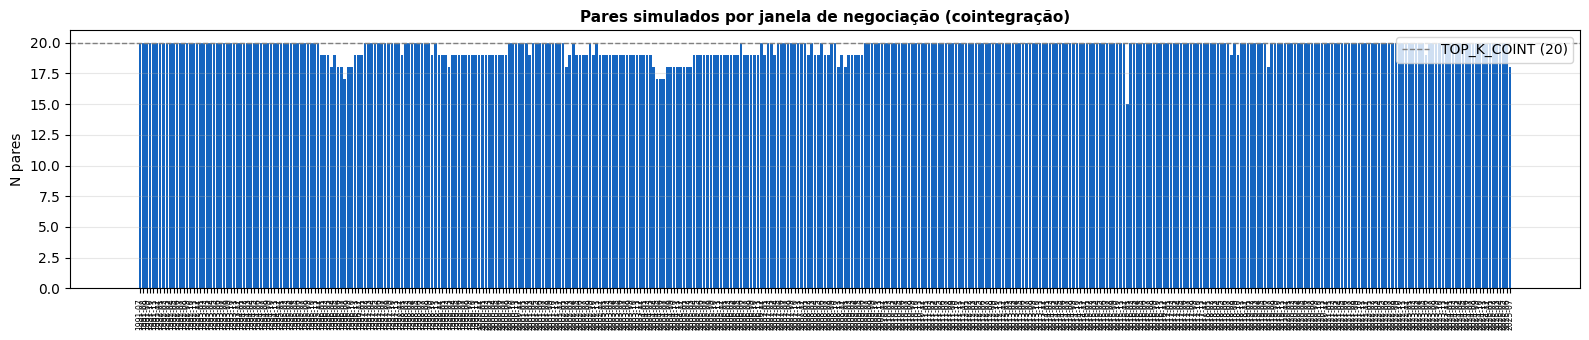

Janelas com 0 pares: 0
Média por janela   : 19.6
Mín / Máx          : 15 / 20


In [69]:
# Diagnóstico: pares simulados por janela de negociação
pares_por_janela = (
    resultados_df
    .groupby('neg_inicio')['ativo1']
    .count()
    .reset_index()
    .rename(columns={'ativo1': 'n_simulados'})
    .sort_values('neg_inicio')
)

fig, ax = plt.subplots(figsize=(16, 3.5))
cores = ['#1565C0' if n >= 10 else '#ef5350' for n in pares_por_janela['n_simulados']]
ax.bar(pares_por_janela['neg_inicio'], pares_por_janela['n_simulados'], color=cores)
ax.axhline(pares['rank'].max(), color='gray', lw=1.0, ls='--',
           label=f'TOP_K_COINT ({pares["rank"].max()})')
ax.set_title('Pares simulados por janela de negociação (cointegração)', fontsize=11, fontweight='bold')
ax.set_ylabel('N pares')
ax.tick_params(axis='x', rotation=90, labelsize=5.5)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Janelas com 0 pares: {(pares_por_janela['n_simulados'] == 0).sum()}")
print(f"Média por janela   : {pares_por_janela['n_simulados'].mean():.1f}")
print(f"Mín / Máx          : {pares_por_janela['n_simulados'].min()} / {pares_por_janela['n_simulados'].max()}")

In [70]:
pares_com_trade = resultados_df[resultados_df['n_trades'] > 0]

print("=== Estatísticas de trades ===")
print(f"Pares que abriram ≥ 1 trade    : {len(pares_com_trade):,} de {len(resultados_df):,}")
print(f"Total de trades abertos        : {resultados_df['n_trades'].sum():,}")
print(f"Trades fechados normalmente    : {resultados_df['n_fechados'].sum():,}")
print(f"Trades forçados (fim período)  : {resultados_df['n_forcados'].sum():,}")

if resultados_df['n_trades'].sum() > 0:
    taxa_convergencia = resultados_df['n_fechados'].sum() / resultados_df['n_trades'].sum()
    print(f"\nTaxa de convergência           : {taxa_convergencia:.1%}")

print("\n=== Retorno por par ===")
print(resultados_df['retorno_total'].describe().to_string())

=== Estatísticas de trades ===
Pares que abriram ≥ 1 trade    : 7,963 de 8,036
Total de trades abertos        : 17,695
Trades fechados normalmente    : 11,250
Trades forçados (fim período)  : 6,445

Taxa de convergência           : 63.6%

=== Retorno por par ===
count    8036.000000
mean        0.034399
std         0.163837
min        -1.013469
25%        -0.043140
50%         0.025383
75%         0.091334
max         2.548396


In [71]:
print("Top 10 pares por retorno total:")
display(
    resultados_df
    .nlargest(10, 'retorno_total')
    [['neg_inicio', 'ativo1', 'ativo2', 'rank', 'beta', 'n_trades', 'n_fechados', 'retorno_total']]
    .reset_index(drop=True)
)

print("\nBottom 10 pares por retorno total:")
display(
    resultados_df
    .nsmallest(10, 'retorno_total')
    [['neg_inicio', 'ativo1', 'ativo2', 'rank', 'beta', 'n_trades', 'n_fechados', 'retorno_total']]
    .reset_index(drop=True)
)

Top 10 pares por retorno total:


,neg_inicio,ativo1,ativo2,rank,beta,n_trades,n_fechados,retorno_total
0,2008-08,MHFI,SPGI,1,0.995645,17,17,2.548396
1,2008-07,MHFI,SPGI,1,1.003889,14,14,2.164235
2,2008-06,MHFI,SPGI,1,1.003927,14,14,2.090868
3,2008-09,MHFI,SPGI,2,0.985389,13,13,2.077056
4,2008-05,MHFI,SPGI,1,1.002698,13,12,1.577915
5,2000-01,MHFI,SPGI,2,0.946958,18,17,1.340965
6,2011-08,BF_B,1958Q,1,0.984670,28,28,1.324016
7,2011-08,MHFI,SPGI,13,1.013159,24,24,1.321880
8,1999-01,MHFI,SPGI,14,0.965206,23,23,1.301584
9,2011-07,BF_B,1958Q,3,1.000419,27,27,1.287238



Bottom 10 pares por retorno total:


,neg_inicio,ativo1,ativo2,rank,beta,n_trades,n_fechados,retorno_total
0,2008-06,8394653Q,PLD,8,0.939614,2,1,-1.013469
1,2007-05,SCHW,ABKFQ,8,1.257080,2,1,-0.769849
2,2008-06,CBS,EQ,19,1.026047,1,0,-0.760444
3,2007-05,PNC,ABKFQ,13,0.921914,2,1,-0.726346
4,2008-08,BVSN,NI,7,0.864931,1,0,-0.621531
5,2008-06,SSP,SE,15,0.869757,1,0,-0.602838
6,2025-03,LOW,IT,15,0.855051,1,0,-0.579671
7,2004-06,KO,STR,11,0.865921,1,0,-0.529607
8,1997-09,363096Q,4621824Q,17,0.838175,1,0,-0.517120
9,2021-02,CSX,NUE,9,0.988064,2,1,-0.512370


## 7. Portfólio e curva de equity

O retorno diário do portfólio é a **média dos retornos de todos os pares** na convenção escolhida:

- **`COMMITTED_CAPITAL = True`** (Rad et al., 2016): todos os N pares entram no denominador todos os dias. Pares sem posição contribuem 0.
- **`COMMITTED_CAPITAL = False`** ("fully invested"): apenas pares com posição ativa entram na média.

In [72]:
portfolio = pd.Series(
    {date: np.mean(rets) for date, rets in retornos_por_data.items()}
).sort_index()

equity = (1 + portfolio).cumprod()

print(f"Período do portfólio: {portfolio.index[0].date()} → {portfolio.index[-1].date()}")
print(f"Dias de negociação  : {len(portfolio):,}")
print(f"Retorno diário médio: {portfolio.mean():.4%}")
print(f"Retorno acumulado   : {equity.iloc[-1] - 1:.2%}")

Período do portfólio: 1991-07-01 → 2025-12-31
Dias de negociação  : 8,688
Retorno diário médio: 0.0274%
Retorno acumulado   : 958.41%


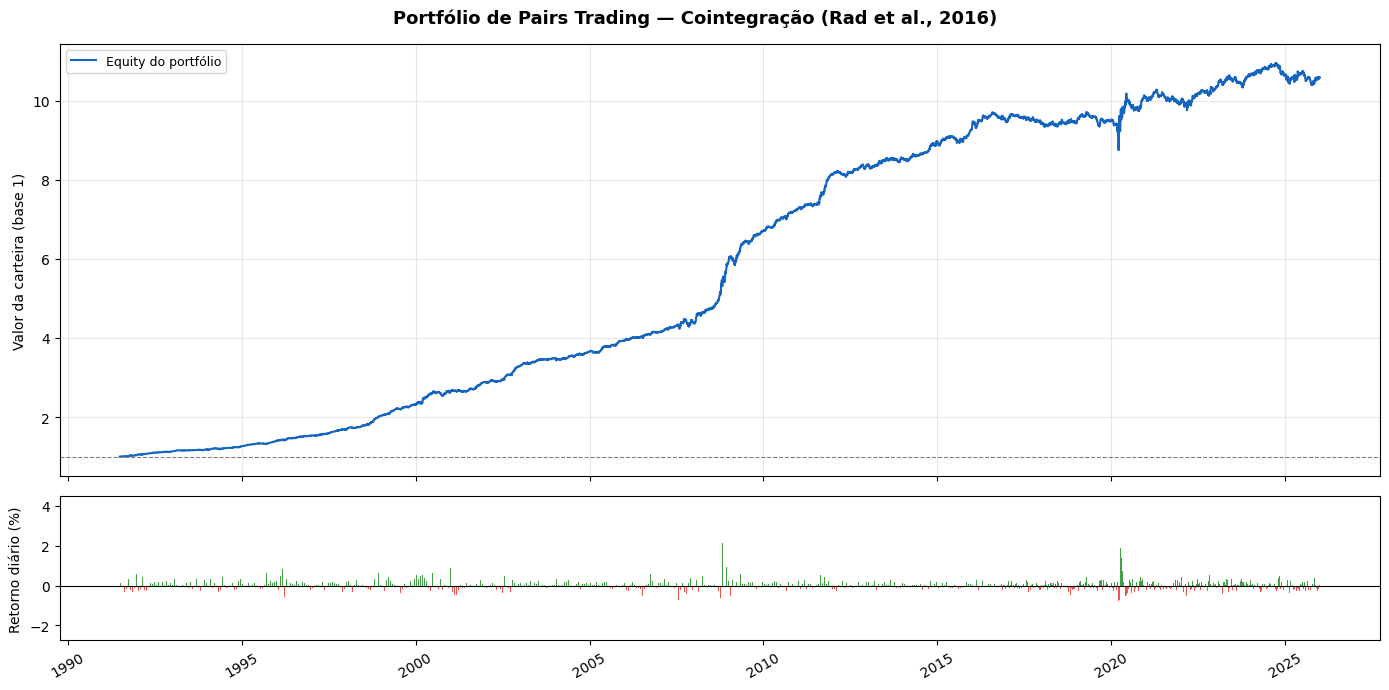

In [73]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle("Portfólio de Pairs Trading — Cointegração (Rad et al., 2016)",
             fontsize=13, fontweight='bold')

ax_eq = axes[0]
ax_eq.plot(equity.index, equity.values, color='#1565C0', lw=1.5, label='Equity do portfólio')
ax_eq.axhline(1, color='gray', lw=0.8, ls='--')
ax_eq.set_ylabel('Valor da carteira (base 1)', fontsize=10)
ax_eq.legend(fontsize=9)
ax_eq.grid(alpha=0.3)

ax_ret = axes[1]
colors = ['#ef5350' if r < 0 else '#43A047' for r in portfolio.values]
ax_ret.bar(portfolio.index, portfolio.values * 100, color=colors, width=1)
ax_ret.axhline(0, color='black', lw=0.8)
ax_ret.set_ylabel('Retorno diário (%)', fontsize=10)
ax_ret.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_ret.xaxis.set_major_locator(mdates.YearLocator(5))
ax_ret.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 8. Métricas de performance

In [74]:
sharpe             = portfolio.mean() / portfolio.std() * np.sqrt(252)
rolling_max        = equity.cummax()
drawdown           = (equity - rolling_max) / rolling_max
max_dd             = drawdown.min()
n_anos             = len(portfolio) / 252
retorno_anualizado = equity.iloc[-1] ** (1 / n_anos) - 1
dias_positivos     = (portfolio > 0).mean()

print("=" * 40)
print("     MÉTRICAS DE PERFORMANCE")
print("=" * 40)
print(f"Retorno acumulado      : {equity.iloc[-1] - 1:>+.2%}")
print(f"Retorno anualizado     : {retorno_anualizado:>+.2%}")
print(f"Volatilidade anual     : {portfolio.std() * np.sqrt(252):>.2%}")
print(f"Sharpe ratio           : {sharpe:>+.2f}")
print(f"Drawdown máximo        : {max_dd:>+.2%}")
print(f"Dias com retorno > 0   : {dias_positivos:.1%}")
print("=" * 40)

     MÉTRICAS DE PERFORMANCE
Retorno acumulado      : +958.41%
Retorno anualizado     : +7.08%
Volatilidade anual     : 3.64%
Sharpe ratio           : +1.90
Drawdown máximo        : -9.95%
Dias com retorno > 0   : 54.3%


Meses positivos: 294 de 414  (71%)


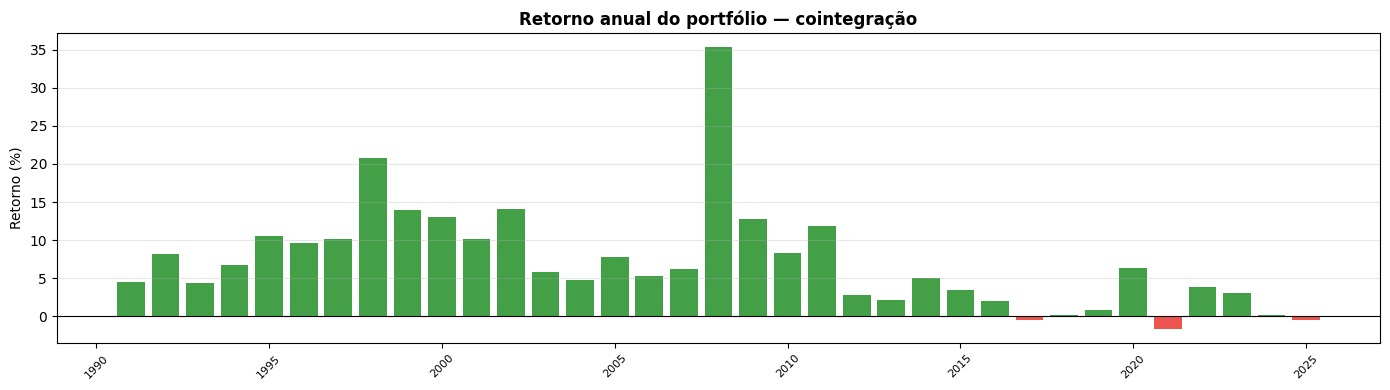

In [75]:
# Retorno por mês de negociação
port_df = portfolio.to_frame('retorno')
port_df['ano'] = port_df.index.year
port_df['mes'] = port_df.index.month
port_df['ano_mes'] = port_df.index.to_period('M').astype(str)

retorno_mensal = (
    port_df.groupby('ano_mes')['retorno']
    .apply(lambda r: (1 + r).prod() - 1)
    .reset_index()
    .rename(columns={'retorno': 'retorno_mensal'})
)

print(f"Meses positivos: {(retorno_mensal['retorno_mensal'] > 0).sum()} "
      f"de {len(retorno_mensal)}  ({(retorno_mensal['retorno_mensal'] > 0).mean():.0%})")

# Agrega por ano para o gráfico (menos poluído)
retorno_anual = (
    port_df.groupby('ano')['retorno']
    .apply(lambda r: (1 + r).prod() - 1)
    .reset_index()
    .rename(columns={'retorno': 'retorno_anual'})
)

fig, ax = plt.subplots(figsize=(14, 4))
cores = ['#43A047' if r > 0 else '#ef5350' for r in retorno_anual['retorno_anual']]
ax.bar(retorno_anual['ano'], retorno_anual['retorno_anual'] * 100, color=cores)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Retorno anual do portfólio — cointegração', fontsize=12, fontweight='bold')
ax.set_ylabel('Retorno (%)')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Explorando um par específico

Altere as variáveis abaixo para visualizar qualquer par em qualquer janela.

In [76]:
# === Configuração: escolha o par a explorar ===
NEG_INICIO_ALVO = resultados_df['neg_inicio'].iloc[0]  # primeiro período disponível
RANK_ALVO       = 1

par_info = pares[
    (pares['negociacao_inicio'] == NEG_INICIO_ALVO) &
    (pares['rank'] == RANK_ALVO)
].squeeze()

print(f"Par selecionado    : {par_info['ativo1']} / {par_info['ativo2']}")
print(f"Janela             : {par_info['janela']}")
print(f"Negociação         : {par_info['negociacao_inicio']} → {par_info['negociacao_fim']}")
print(f"Beta (hedge ratio) : {par_info['beta']:.4f}")
print(f"Alpha (intercepto) : {par_info['alpha']:.4f}")
print(f"ADF stat           : {par_info['adf_stat']:.4f}")
print(f"Spread μ           : {par_info['spread_media']:.6f}")
print(f"Spread σ           : {par_info['spread_desvio']:.6f}")

Par selecionado    : GPUI / FPC
Janela             : 1990-07_a_1991-06
Negociação         : 1991-07 → 1991-12
Beta (hedge ratio) : 1.0034
Alpha (intercepto) : -0.0067
ADF stat           : -4.5274
Spread μ           : 0.000000
Spread σ           : 0.017695


In [77]:
a1 = par_info['ativo1']
a2 = par_info['ativo2']

form_inicio = pd.Period(par_info['formacao_inicio'], freq='M')
form_fim    = pd.Period(par_info['formacao_fim'],    freq='M')
neg_inicio  = pd.Period(par_info['negociacao_inicio'], freq='M')
neg_fim     = pd.Period(par_info['negociacao_fim'],    freq='M')

mask_form = (meses_por_linha >= form_inicio) & (meses_por_linha <= form_fim)
mask_neg  = (meses_por_linha >= neg_inicio)  & (meses_por_linha <= neg_fim)

precos_form = df.loc[mask_form, [a1, a2]].dropna()
precos_neg  = df.loc[mask_neg,  [a1, a2]].dropna()

resultado = simular_par_coint(
    precos_form, precos_neg,
    par_info['alpha'], par_info['beta'],
    par_info['spread_media'], par_info['spread_desvio']
)

if resultado is None:
    print("Par não pode ser simulado.")
else:
    n_ab, n_fec, n_for = contar_trades(resultado['position'].values)
    retorno = resultado['retorno_diario'].sum()
    print(f"Trades abertos  : {n_ab}")
    print(f"Fechados (z→0)  : {n_fec}")
    print(f"Forçados        : {n_for}")
    print(f"Retorno total   : {retorno:+.4%}")

Trades abertos  : 2
Fechados (z→0)  : 1
Forçados        : 1
Retorno total   : +2.4147%


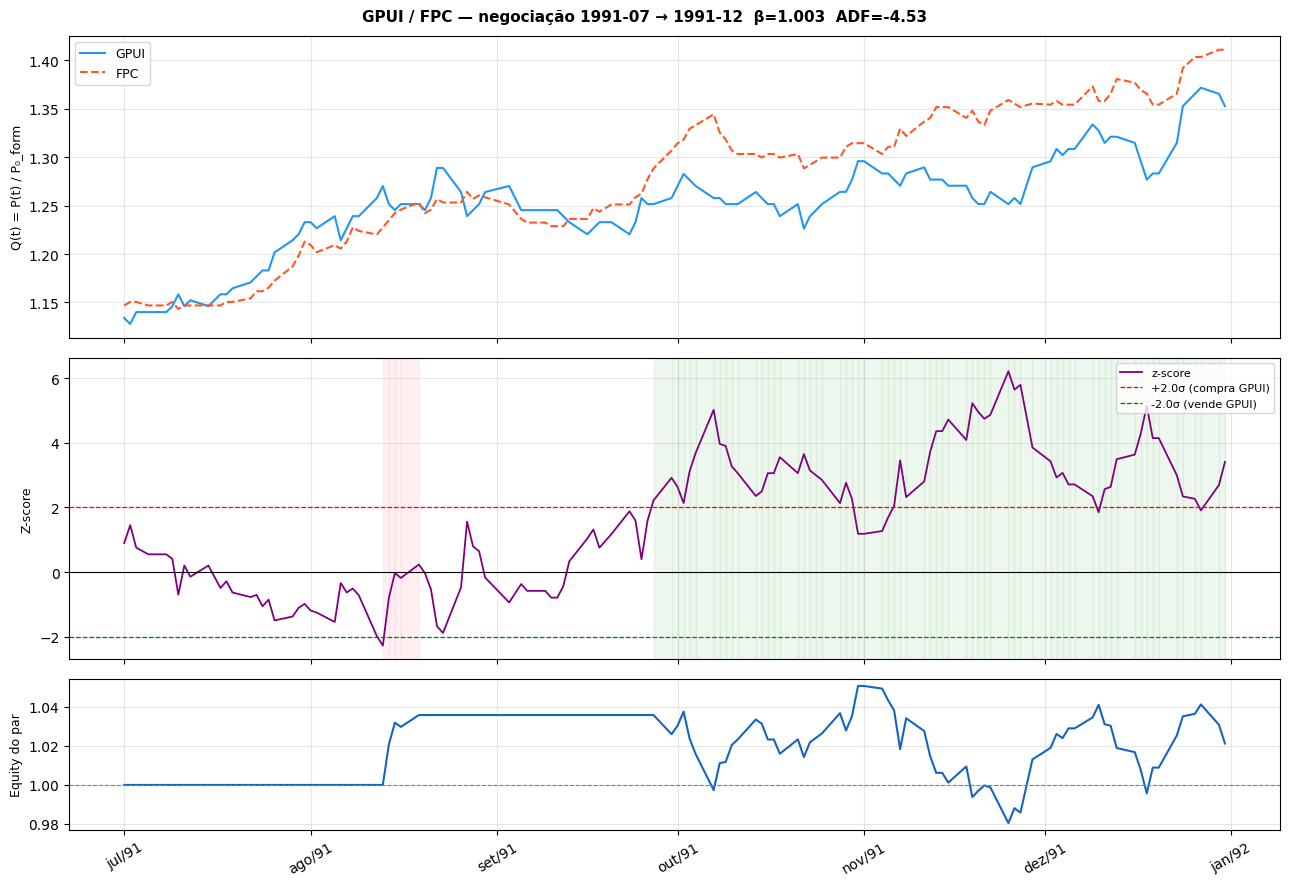

In [78]:
if resultado is not None:
    P0    = precos_form.sort_index().iloc[0]
    Q_neg = precos_neg / P0
    equity_par = (1 + resultado['retorno_diario']).cumprod()

    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True,
                              gridspec_kw={'height_ratios': [2, 2, 1]})
    fig.suptitle(
        f"{a1} / {a2} — negociação {par_info['negociacao_inicio']} → {par_info['negociacao_fim']}  "
        f"β={par_info['beta']:.3f}  ADF={par_info['adf_stat']:.2f}",
        fontsize=11, fontweight='bold'
    )

    # Painel 1: preços normalizados Q(t) no período de negociação
    ax1 = axes[0]
    ax1.plot(Q_neg.index, Q_neg[a1], color='#2196F3', lw=1.5, label=a1)
    ax1.plot(Q_neg.index, Q_neg[a2], color='#FF5722', lw=1.5, ls='--', label=a2)
    ax1.set_ylabel('Q(t) = P(t) / P₀_form', fontsize=9)
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)

    # Painel 2: z-score com sinais de entrada/saída
    ax2 = axes[1]
    ax2.plot(resultado.index, resultado['z'], color='purple', lw=1.3, label='z-score')
    ax2.axhline(0,      color='black', lw=0.8)
    ax2.axhline(+DELTA, color='red',   lw=0.9, ls='--', label=f'+{DELTA}σ (compra {a1})')
    ax2.axhline(-DELTA, color='green', lw=0.9, ls='--', label=f'-{DELTA}σ (vende {a1})')
    if STOP is not None:
        ax2.axhline(+STOP, color='red',   lw=0.7, ls=':', alpha=0.5)
        ax2.axhline(-STOP, color='green', lw=0.7, ls=':', alpha=0.5)

    pos = resultado['position'].values
    datas = resultado.index
    for t in range(len(pos)):
        if pos[t] != 0:
            cor = '#C8E6C9' if pos[t] == +1 else '#FFCDD2'
            ax2.axvspan(datas[t], datas[min(t + 1, len(datas) - 1)], alpha=0.3, color=cor)

    ax2.set_ylabel('Z-score', fontsize=9)
    ax2.legend(fontsize=8, loc='upper right')
    ax2.grid(alpha=0.3)

    # Painel 3: equity acumulada do par
    ax3 = axes[2]
    ax3.plot(equity_par.index, equity_par.values, color='#1565C0', lw=1.5)
    ax3.axhline(1, color='gray', lw=0.8, ls='--')
    ax3.set_ylabel('Equity do par', fontsize=9)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax3.tick_params(axis='x', rotation=30)
    ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 10. Salvando resultados

In [79]:
resultados_df.to_csv('output/negociacao_pares_coint.csv', index=False)
portfolio.to_frame('retorno_diario').to_csv('output/negociacao_portfolio_coint.csv')

print("Salvo:")
print("  output/negociacao_pares_coint.csv     — resultado por par")
print("  output/negociacao_portfolio_coint.csv — retorno diário do portfólio")

Salvo:
  output/negociacao_pares_coint.csv     — resultado por par
  output/negociacao_portfolio_coint.csv — retorno diário do portfólio
